# Applying AstroLink to Image Data (a JWST toy example)

This notebook demonstrates how one might apply **AstroLink** -- which is designed for *point-cloud data* -- to *image data*. Here, we use a toy example based on the JWST Deep Field image, however the general idea can be extrapolated to any image with some number of *colour* channels.

We'll:
1. Load an image and interpret it as a luminosity map.
2. Sample points from the image proportionally to its luminosity.
3. Represent sampled points as a point-cloud with colour channels.
4. Apply AstroLink to identify coherent structures.
5. Visualize the results and the steps taken.

> [!NOTE]
> This is an experimental application setting, but it allows for image-based structure-finding in a model-agnostic way.

Obligatory imports...

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from astrolink import AstroLink

## 1. Load the Image

We load a JWST Deep Field image (`Webb_Deep_Field.tif`) as a NumPy array. Each pixel has RGB values that we'll later use for sampling and visualization.

In [17]:
I = plt.imread('../data/Webb_Deep_Field.tif')

## 2. Generate a Point Cloud from the Image

We convert the image into a **point-cloud** where each sampled point represents a pixel location and its color. Here, sampling is performed **proportionally to pixel luminosity**, emphasizing brighter regions.

To summarise, we;
- Subtract background luminosity.
- Normalize and compute the cumulative distribution function (CDF).
- Randomly sample pixels according to their relative brightness.

In [18]:
# Sample proportional to luminosity
n_samples = 10**6  # Number of samples
lum = np.linalg.norm(I, axis=-1)
lum = np.maximum(lum - 50 * np.sqrt(3), 0)  # Subtract background
lum /= lum.max()  # Normalize

# CDF-based sampling
cdf = np.cumsum(lum)
cdf /= cdf[-1]
cdf_sampling = np.random.uniform(0, 1, n_samples)
pixel_idx = cdf.searchsorted(cdf_sampling).reshape(-1, 1).astype(np.float64)

# Recover pixel coordinates
x, y = pixel_idx % I.shape[1], pixel_idx // I.shape[1]
pixel_colours = I.reshape(-1, I.shape[-1])
P = np.concatenate((x, y, pixel_colours[pixel_idx.astype(np.int64).ravel()]), axis=-1)
P += 0.5 # Centered the points in the pixel
P += np.random.uniform(-0.5, 0.5, P.shape) # Add random uniform noise to randomly distribute the points in their respective pixels and within the integer colour values
P[:, 2:] *= 255 / 266  # Adjust colour scale to ensure its contained within [0, 1] for plotting

## 3. Apply AstroLink

We now apply **AstroLink** to the sampled point-cloud to find coherent structures.

- `k_den = 50`: number of neighbors for density estimation.  
- `adaptive = 0`: disables unit variance rescaling.
- `S = 5`: clusters will be $5\sigma$ outliers from the noisy density fluctuations in the sampled point-cloud.

In [19]:
c = AstroLink(P, k_den=50, adaptive=0, S=5)
c.run()

## 4. Visualize Results

To visualize the results (and this entire process), we create a 2×2 grid of plots showing the:
1. Original image
2. Luminosity map
3. Random sampling with reassigned colours
4. Clustered data (in distinct colours)

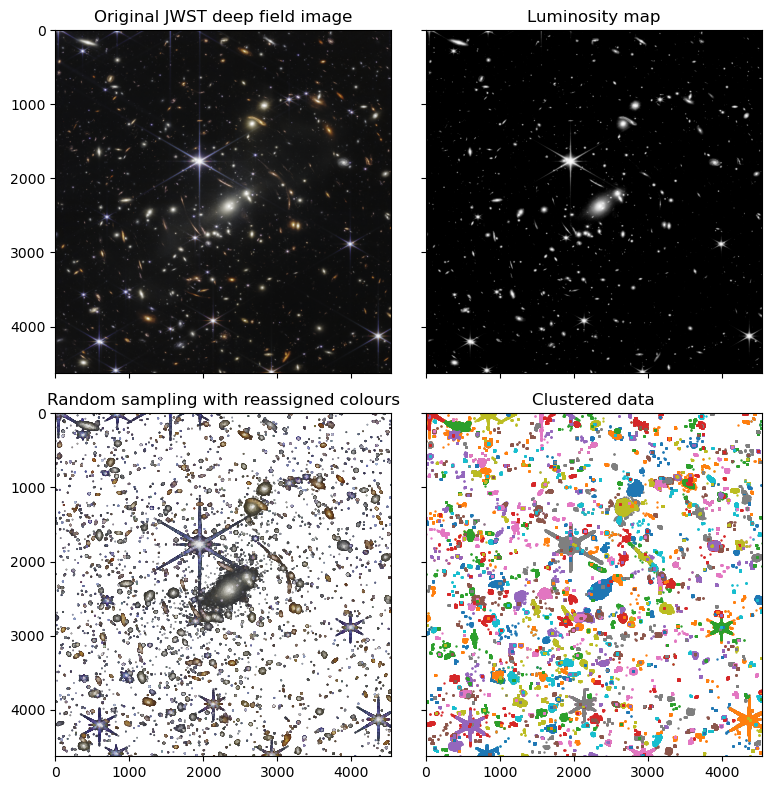

In [20]:
fig, axs = plt.subplots(2, 2, figsize=(8, 8), sharex=True, sharey=True)

# Original image
axs[0, 0].imshow(I)
axs[0, 0].set_title('Original JWST deep field image')
axs[0, 0].set_aspect('equal')

# Luminosity map
axs[0, 1].imshow(lum, cmap='Greys_r')
axs[0, 1].set_title('Luminosity map')
axs[0, 1].set_aspect('equal')

# Randomly sampled points
axs[1, 0].scatter(P[:, 0], P[:, 1], c=P[:, 2:]/255, s=0.1)
axs[1, 0].set_title('Random sampling with reassigned colours')
axs[1, 0].set_aspect('equal')

# Clustered data
colours = [f"C{i}" for i in range(10)]
for i, (start, end) in enumerate(c.clusters[1:]):
    clustered_points = P[c.ordering[start:end]][:, :2]
    axs[1, 1].scatter(clustered_points[:, 0], clustered_points[:, 1], c=colours[i % 10], s=0.5)
axs[1, 1].set_title('Clustered data')
axs[1, 1].set_aspect('equal')

# Consistent limits
axs[0, 0].set(xlim=(0, I.shape[1]), ylim=(I.shape[0], 0))

plt.tight_layout()
plt.show()

## Summary

This notebook demonstrated how to adapt **AstroLink**, originally developed for astronomical point-cloud data, to image data. By interpreting pixel intensities as a probability distribution for sampling, we can uncover latent spatial and structural patterns in images.

---

**This process can be improved, some next steps could be:**
- Try varying the number of points sampled from the image ($n=10^6$ is very small compared to the number of pixels ~$2\times10^7$).
- Try varying the background cutoff.
- Construct the point-cloud sample more smoothly, ensuring continuity despite pixel-boundaries and colour-discreteness to avoid sharp pixel-edge effects.
- Apply a meaningful relative rescaling of the position-space to the colour-space for improved structure identification.
- Try varying `k_den` or `S` to see how cluster granularity changes.
- Try *keeping* only the background, instead of *removing* it, to see find faint structures.
- Apply the same technique to real astronomical images or multi-band data :)